# Notebook 06: CNN Development

---

## Overview

This notebook develops a **custom Convolutional Neural Network (CNN)** for multi-label chest X-ray disease classification.

**Objectives:**
1. Build efficient TensorFlow data pipelines with augmentation
2. Design custom CNN architecture for medical imaging
3. Train multi-label classification model with class weights
4. Implement callbacks for early stopping and model checkpointing
5. Evaluate and compare against baseline models
6. Visualize learned features and predictions

**Key Difference from Notebook 05:**
- **Notebook 05**: Hand-crafted features (HOG, GLCM) → Traditional ML
- **This Notebook**: CNN learns features automatically from raw pixels

**Outputs:**
- Trained CNN model (H5 format)
- Training history and metrics
- Performance comparison with baselines
- Sample predictions with visualizations

---

## 💡 CNNs vs Traditional ML: The Paradigm Shift

### Traditional ML (Notebook 05)

```
Raw Image → Hand-Crafted Features → ML Model → Prediction
 (X-ray)    (HOG, GLCM, Stats)      (LogReg)   (Diseases)
            ↑
         WE design features
```

**Limitations:**
- Requires domain expertise to design features
- Features might miss important patterns
- Fixed feature representation (can't adapt)

### Deep Learning (This Notebook)

```
Raw Image → CNN Layers → Learned Features → Prediction
 (X-ray)    (Conv+Pool)  (Automatic)        (Diseases)
                         ↑
                   MODEL learns features
```

**Advantages:**
- Learns features directly from data
- Discovers patterns humans might miss
- Adapts features to the specific task
- Hierarchical learning: edges → textures → organs → diseases

---

### How CNNs Work: Layer by Layer

**Input Layer (224×224×3)**
- Raw pixel values from X-ray image
- 3 channels (RGB, converted from grayscale)

**Convolutional Layers**
- Apply small filters (3×3, 5×5) that slide across image
- Each filter detects specific patterns (edges, textures)
- Early layers: Simple patterns (horizontal/vertical edges)
- Deep layers: Complex patterns (ribs, lung boundaries, masses)

**Pooling Layers**
- Reduce spatial dimensions (224×224 → 112×112 → 56×56...)
- Make model robust to small translations
- Reduce computation and parameters

**Dense Layers**
- Combine learned features to make final predictions
- 14 output neurons (one per disease)
- Sigmoid activation (multi-label: each disease is independent)

---

### Analogy to Traditional ML

**Traditional ML:**
```python
# Step 1: Manual feature engineering
features = extract_hog(image) + extract_glcm(image)

# Step 2: Train classifier
model = LogisticRegression()
model.fit(features, labels)
```

**Deep Learning:**
```python
# Step 1+2 combined: Model learns BOTH features AND classification
model = CNN()
model.fit(raw_images, labels)  # No manual feature engineering!
```

The CNN **automatically discovers** what HOG, GLCM, and other features to extract through training!

---

## 1. Setup and Configuration

In [66]:
# Import libraries
import json
import sys
import warnings
from pathlib import Path

# Data manipulation
import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Deep learning
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models, callbacks
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Metrics
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
    roc_curve,
)

# Configuration
warnings.filterwarnings('ignore')
np.random.seed(42)
tf.random.set_seed(42)

print("✓ Libraries imported successfully")
print(f"TensorFlow version: {tf.__version__}")
print(f"GPU available: {len(tf.config.list_physical_devices('GPU'))} GPUs")

✓ Libraries imported successfully
TensorFlow version: 2.18.1
GPU available: 0 GPUs


In [67]:
# Define paths
current_path = Path.cwd()

if current_path.name == 'jupyter_notebooks':
    PROJECT_ROOT = current_path.parent
elif (current_path / 'setup.py').exists() or (current_path / 'README.md').exists():
    PROJECT_ROOT = current_path
else:
    PROJECT_ROOT = current_path.parent

DATA_DIR = PROJECT_ROOT / 'data'
PROCESSED_DIR = DATA_DIR / 'processed'
OUTPUTS_DIR = PROJECT_ROOT / 'outputs'
FIGURES_DIR = OUTPUTS_DIR / 'figures'
MODELS_DIR = PROJECT_ROOT / 'models' / 'saved_models'

# Create directories
MODELS_DIR.mkdir(exist_ok=True, parents=True)

print(f"Project root: {PROJECT_ROOT}")
print(f"Processed data: {PROCESSED_DIR}")
print(f"Models directory: {MODELS_DIR}")

Project root: /Users/james/CodeInstitute/CapStone
Processed data: /Users/james/CodeInstitute/CapStone/data/processed
Models directory: /Users/james/CodeInstitute/CapStone/models/saved_models


In [68]:
# CNN Configuration
CONFIG = {
    # Image parameters
    'img_height': 224,
    'img_width': 224,
    'channels': 3,
    
    # Training parameters
    'batch_size': 32,
    'epochs': 50,
    'learning_rate': 0.001,
    
    # Model architecture
    'filters': [32, 64, 128, 256],  # Filters per conv block
    'dense_units': 512,
    'dropout_rate': 0.5,
    
    # Regularization
    'l2_reg': 0.0001,
    
    # Callbacks
    'early_stopping_patience': 10,
    'reduce_lr_patience': 5,
    
    # Data
    'num_classes': 14,
    'use_sample': True,  # Use sample for faster training
    'sample_size': 5000,
    
    'random_state': 42
}

print("CNN Configuration:")
for key, value in CONFIG.items():
    print(f"  {key}: {value}")

CNN Configuration:
  img_height: 224
  img_width: 224
  channels: 3
  batch_size: 32
  epochs: 50
  learning_rate: 0.001
  filters: [32, 64, 128, 256]
  dense_units: 512
  dropout_rate: 0.5
  l2_reg: 0.0001
  early_stopping_patience: 10
  reduce_lr_patience: 5
  num_classes: 14
  use_sample: True
  sample_size: 5000
  random_state: 42


## Model Training Configuration

**⚙️ RETRAIN_MODEL Flag:**

Set to `True` to retrain the CNN from scratch (takes 30-60 min on CPU, 5-10 min on GPU).
Set to `False` to use the saved model if available (instant evaluation).

This is useful when:
- ✅ **False**: Re-running the notebook for evaluation/analysis without waiting for training
- ✅ **True**: Changing architecture, hyperparameters, or training on different data

In [87]:
# Training control flag
RETRAIN_MODEL = False  # Set to True to retrain from scratch

print(f"Model Training Mode: {'RETRAIN FROM SCRATCH' if RETRAIN_MODEL else 'USE SAVED IF AVAILABLE'}")

Model Training Mode: USE SAVED IF AVAILABLE


## 2. Load Data Splits and Class Weights

In [70]:
# Load split files
train_df = pd.read_csv(PROCESSED_DIR / 'train_split.csv')
val_df = pd.read_csv(PROCESSED_DIR / 'val_split.csv')
test_df = pd.read_csv(PROCESSED_DIR / 'test_split.csv')

print(f"✓ Loaded splits:")
print(f"  Train: {len(train_df):,} images")
print(f"  Val:   {len(val_df):,} images")
print(f"  Test:  {len(test_df):,} images")

# Load preprocessing config
with open(PROCESSED_DIR / 'preprocessing_config.json', 'r') as f:
    prep_config = json.load(f)

disease_classes = prep_config['disease_classes']
class_weights_dict = prep_config['class_weights']

print(f"\n✓ Disease classes: {len(disease_classes)}")
print(f"✓ Class weights loaded")

✓ Loaded splits:
  Train: 78,831 images
  Val:   16,383 images
  Test:  16,890 images

✓ Disease classes: 14
✓ Class weights loaded


In [71]:
# Optionally sample for faster experimentation
if CONFIG['use_sample']:
    sample_size = CONFIG['sample_size']
    train_df = train_df.sample(n=min(sample_size, len(train_df)), random_state=42)
    val_df = val_df.sample(n=min(sample_size // 5, len(val_df)), random_state=42)
    test_df = test_df.sample(n=min(sample_size // 5, len(test_df)), random_state=42)
    
    print(f"⚠️ Using sample mode for faster training:")
    print(f"  Train: {len(train_df):,} images")
    print(f"  Val:   {len(val_df):,} images")
    print(f"  Test:  {len(test_df):,} images")
    print(f"\n  💡 Set CONFIG['use_sample'] = False to use full dataset")
else:
    print("Using full dataset")

# Reset indices
train_df = train_df.reset_index(drop=True)
val_df = val_df.reset_index(drop=True)
test_df = test_df.reset_index(drop=True)

⚠️ Using sample mode for faster training:
  Train: 5,000 images
  Val:   1,000 images
  Test:  1,000 images

  💡 Set CONFIG['use_sample'] = False to use full dataset


## 3. TensorFlow Data Generators

### 📚 What We're Doing

**The Memory Problem:**
- Each 224×224×3 image = 150,528 bytes
- 78,831 training images × 150KB = **~11.8 GB**
- Can't load all images into RAM at once!

**Solution: Data Generators**

Generators load images **on-the-fly** in small batches:
```python
# Instead of:
X_train = load_all_images()  # ❌ 12 GB RAM!

# We use:
generator = ImageDataGenerator()  # ✓ Only 32 images at a time
for batch in generator:
    train_on_batch(batch)  # Load → Train → Discard → Next batch
```

**Analogy to Traditional ML:**

This is like **mini-batch gradient descent** vs full-batch:
- **Full-batch**: Calculate gradient using ALL samples (memory intensive)
- **Mini-batch**: Calculate gradient using small batches (memory efficient)

**Benefits:**
1. **Memory efficient**: Only load `batch_size` images at a time
2. **Built-in augmentation**: Apply random transforms on-the-fly
3. **Multi-threading**: Load next batch while GPU trains current batch

---

### ImageDataGenerator Configuration

**Training generator (with augmentation):**
- Rescale pixels: 0-255 → 0-1
- Horizontal flip: Simulate different patient positioning
- Rotation: ±15 degrees
- Shifts: ±10% horizontal/vertical
- Zoom: ±10%

**Validation/Test generators (no augmentation):**
- Only rescale pixels
- Consistent evaluation

---

In [72]:
# Training data generator with augmentation
train_datagen = ImageDataGenerator(
    rescale=1./255,
    horizontal_flip=True,
    rotation_range=15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.1,
)

# Validation/test generators (no augmentation)
val_datagen = ImageDataGenerator(rescale=1./255)
test_datagen = ImageDataGenerator(rescale=1./255)

print("✓ ImageDataGenerators created")
print("  Train: With augmentation (flip, rotate, shift, zoom)")
print("  Val/Test: Rescale only")

✓ ImageDataGenerators created
  Train: With augmentation (flip, rotate, shift, zoom)
  Val/Test: Rescale only


In [73]:
# Create flow_from_dataframe generators
train_generator = train_datagen.flow_from_dataframe(
    dataframe=train_df,
    x_col='full_path',
    y_col=disease_classes,
    target_size=(CONFIG['img_height'], CONFIG['img_width']),
    batch_size=CONFIG['batch_size'],
    class_mode='raw',  # Multi-label (not categorical)
    shuffle=True,
    seed=CONFIG['random_state']
)

val_generator = val_datagen.flow_from_dataframe(
    dataframe=val_df,
    x_col='full_path',
    y_col=disease_classes,
    target_size=(CONFIG['img_height'], CONFIG['img_width']),
    batch_size=CONFIG['batch_size'],
    class_mode='raw',
    shuffle=False
)

test_generator = test_datagen.flow_from_dataframe(
    dataframe=test_df,
    x_col='full_path',
    y_col=disease_classes,
    target_size=(CONFIG['img_height'], CONFIG['img_width']),
    batch_size=CONFIG['batch_size'],
    class_mode='raw',
    shuffle=False
)

print(f"\n✓ Data generators ready")
print(f"  Train batches per epoch: {len(train_generator)}")
print(f"  Val batches: {len(val_generator)}")
print(f"  Test batches: {len(test_generator)}")

Found 5000 validated image filenames.
Found 1000 validated image filenames.
Found 1000 validated image filenames.

✓ Data generators ready
  Train batches per epoch: 157
  Val batches: 32
  Test batches: 32


## 4. Build Custom CNN Architecture

### 📚 Architecture Design

Our CNN follows a classic pattern: **Conv Block → Pool → Flatten → Dense → Output**

```
Input (224×224×3)
    ↓
┌─────────────────────┐
│ Conv Block 1        │  32 filters, 3×3
│ - Conv2D + ReLU     │  → Detects edges, simple patterns
│ - Conv2D + ReLU     │
│ - MaxPooling (2×2)  │  224×224 → 112×112
└─────────────────────┘
    ↓
┌─────────────────────┐
│ Conv Block 2        │  64 filters
│ - Conv2D + ReLU     │  → Detects textures, basic shapes
│ - Conv2D + ReLU     │
│ - MaxPooling (2×2)  │  112×112 → 56×56
└─────────────────────┘
    ↓
┌─────────────────────┐
│ Conv Block 3        │  128 filters
│ - Conv2D + ReLU     │  → Detects organ boundaries, structures
│ - Conv2D + ReLU     │
│ - MaxPooling (2×2)  │  56×56 → 28×28
└─────────────────────┘
    ↓
┌─────────────────────┐
│ Conv Block 4        │  256 filters
│ - Conv2D + ReLU     │  → Detects disease patterns, abnormalities
│ - Conv2D + ReLU     │
│ - MaxPooling (2×2)  │  28×28 → 14×14
└─────────────────────┘
    ↓
Flatten (14×14×256 = 50,176 features)
    ↓
Dense (512 units) + ReLU + Dropout(0.5)
    ↓
Output (14 units) + Sigmoid
    ↓
14 disease probabilities [0-1]
```

### Key Design Choices

**1. Multiple Conv Layers per Block**
- Two 3×3 convolutions have same receptive field as one 5×5
- But with fewer parameters and more non-linearity (2 ReLUs vs 1)

**2. Increasing Filter Depth**
- Start: 32 filters (detect simple patterns)
- End: 256 filters (detect complex disease patterns)
- Hierarchical feature learning

**3. MaxPooling After Each Block**
- Reduces spatial dimensions (saves computation)
- Makes model robust to small translations
- Increases receptive field

**4. Dropout (0.5)**
- Randomly drops 50% of neurons during training
- Prevents overfitting (like L1/L2 regularization in LogReg)
- Forces model to learn robust features

**5. Sigmoid Activation (Not Softmax!)**
- **Softmax**: Forces probabilities to sum to 1 (one disease only)
- **Sigmoid**: Independent probabilities (multiple diseases allowed)
- Perfect for multi-label classification

### Comparison to Tabular ML

**Tabular ML layers:**
```python
Input → Dense(hidden) → Dense(output)
```

**Image CNN layers:**
```python
Input → Conv(features) → Dense(classification) → Output
       ↑
    Replaces manual feature extraction!
```

The Conv layers are **learning the features** that we manually created (HOG, GLCM) in Notebook 05!

---

In [74]:
def build_custom_cnn(input_shape, num_classes, config):
    """
    Build custom CNN architecture for chest X-ray classification.
    
    Args:
        input_shape: (height, width, channels)
        num_classes: Number of disease classes (14)
        config: Configuration dictionary
    
    Returns:
        Compiled Keras model
    """
    # L2 regularization
    l2_reg = keras.regularizers.l2(config['l2_reg'])
    
    model = models.Sequential([
        # Input layer
        layers.Input(shape=input_shape),
        
        # Conv Block 1: 32 filters
        layers.Conv2D(config['filters'][0], (3, 3), activation='relu', 
                      padding='same', kernel_regularizer=l2_reg),
        layers.Conv2D(config['filters'][0], (3, 3), activation='relu', 
                      padding='same', kernel_regularizer=l2_reg),
        layers.MaxPooling2D((2, 2)),
        layers.BatchNormalization(),
        
        # Conv Block 2: 64 filters
        layers.Conv2D(config['filters'][1], (3, 3), activation='relu', 
                      padding='same', kernel_regularizer=l2_reg),
        layers.Conv2D(config['filters'][1], (3, 3), activation='relu', 
                      padding='same', kernel_regularizer=l2_reg),
        layers.MaxPooling2D((2, 2)),
        layers.BatchNormalization(),
        
        # Conv Block 3: 128 filters
        layers.Conv2D(config['filters'][2], (3, 3), activation='relu', 
                      padding='same', kernel_regularizer=l2_reg),
        layers.Conv2D(config['filters'][2], (3, 3), activation='relu', 
                      padding='same', kernel_regularizer=l2_reg),
        layers.MaxPooling2D((2, 2)),
        layers.BatchNormalization(),
        
        # Conv Block 4: 256 filters
        layers.Conv2D(config['filters'][3], (3, 3), activation='relu', 
                      padding='same', kernel_regularizer=l2_reg),
        layers.Conv2D(config['filters'][3], (3, 3), activation='relu', 
                      padding='same', kernel_regularizer=l2_reg),
        layers.MaxPooling2D((2, 2)),
        layers.BatchNormalization(),
        
        # Flatten to 1D
        layers.Flatten(),
        
        # Dense layers with dropout
        layers.Dense(config['dense_units'], activation='relu', 
                     kernel_regularizer=l2_reg),
        layers.Dropout(config['dropout_rate']),
        
        # Output layer: 14 neurons with sigmoid (multi-label)
        layers.Dense(num_classes, activation='sigmoid')
    ])
    
    return model


print("✓ CNN architecture function defined")

✓ CNN architecture function defined


In [75]:
# Build model
input_shape = (CONFIG['img_height'], CONFIG['img_width'], CONFIG['channels'])
model = build_custom_cnn(input_shape, CONFIG['num_classes'], CONFIG)

# Display architecture
model.summary()

print(f"\n✓ Model created")
print(f"  Total parameters: {model.count_params():,}")

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_24 (Conv2D)              │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_25 (Conv2D)              │ (None, 224, 224, 32)   │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_12 (MaxPooling2D) │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_12          │ (None, 112, 112, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_26 (Conv2D)              │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_27 (Conv2D)              │ (None, 112, 112, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_13 (MaxPooling2D) │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_13          │ (None, 56, 56, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_28 (Conv2D)              │ (None, 56, 56, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_29 (Conv2D)              │ (None, 56, 56, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_14 (MaxPooling2D) │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_14          │ (None, 28, 28, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_30 (Conv2D)              │ (None, 28, 28, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_31 (Conv2D)              │ (None, 28, 28, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_15 (MaxPooling2D) │ (None, 14, 14, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_15          │ (None, 14, 14, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (None, 50176)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 512)            │    25,690,624 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 14)             │         7,182 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 26,871,982 (102.51 MB)

 Trainable params: 26,871,022 (102.50 MB)

 Non-trainable params: 960 (3.75 KB)


✓ Model created
  Total parameters: 26,871,982


## 5. Compile Model

### 📚 Loss Function and Optimizer

**Loss Function: Binary Crossentropy**

For **multi-label** classification, we use binary crossentropy (NOT categorical):

```python
# Multi-class (one disease only):
loss = 'categorical_crossentropy'  # Softmax output

# Multi-label (multiple diseases possible):
loss = 'binary_crossentropy'  # Sigmoid output
```

**Why?** Each disease is an independent binary decision:
- Atelectasis: Yes/No
- Cardiomegaly: Yes/No
- ...
- Pneumothorax: Yes/No

Binary crossentropy treats each output independently.

**Analogy to Traditional ML:**
- This is like training 14 separate Logistic Regression models
- Each model predicts one disease (binary classification)
- Same loss function: log loss = binary crossentropy

---

**Optimizer: Adam**

Adam = Adaptive Moment Estimation
- Combines momentum (SGD) + adaptive learning rates (RMSprop)
- Works well for most deep learning tasks
- Default learning rate: 0.001

**Analogy:** Like gradient descent in LogReg, but with smarter step sizes

---

**Metrics: AUC**

We track AUC (Area Under ROC Curve) during training:
- Better metric than accuracy for imbalanced classes
- Measures model's ranking ability
- Same metric we used for baseline models

---

In [76]:
# Compile model
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=CONFIG['learning_rate']),
    loss='binary_crossentropy',  # Multi-label classification
    metrics=[
        'accuracy',
        keras.metrics.AUC(name='auc'),
        keras.metrics.Precision(name='precision'),
        keras.metrics.Recall(name='recall')
    ]
)

print("✓ Model compiled")
print(f"  Optimizer: Adam (lr={CONFIG['learning_rate']})")
print(f"  Loss: Binary Crossentropy (multi-label)")
print(f"  Metrics: Accuracy, AUC, Precision, Recall")

✓ Model compiled
  Optimizer: Adam (lr=0.001)
  Loss: Binary Crossentropy (multi-label)
  Metrics: Accuracy, AUC, Precision, Recall


## 6. Training Callbacks

### 📚 What Are Callbacks?

Callbacks are functions that run during training to monitor and control the process.

**Analogy to Traditional ML:**
- Like early stopping in sklearn: `SGDClassifier(early_stopping=True)`
- Prevents overfitting by monitoring validation performance

---

### Our Callbacks

**1. ModelCheckpoint**
- Saves best model during training
- Monitors validation AUC
- Only saves when model improves
- **Why?** Training might overfit after epoch 20, but we keep best from epoch 15

**2. EarlyStopping**
- Stops training if no improvement for N epochs
- Patience = 10 epochs
- Prevents wasting time on overfitted model
- **Analogy:** Like sklearn's `tol` parameter in LogisticRegression

**3. ReduceLROnPlateau**
- Reduces learning rate when stuck
- If validation loss doesn't improve for 5 epochs → lr = lr × 0.5
- Helps escape local minima
- **Analogy:** Like adaptive learning rates in SGD

**4. CSVLogger**
- Saves training history to CSV
- Loss and metrics for each epoch
- Useful for later analysis

---

In [77]:
# Define callbacks
callback_list = [
    # Save best model
    callbacks.ModelCheckpoint(
        filepath=str(MODELS_DIR / 'cnn_custom_best.h5'),
        monitor='val_auc',
        mode='max',
        save_best_only=True,
        verbose=1
    ),
    
    # Early stopping
    callbacks.EarlyStopping(
        monitor='val_auc',
        mode='max',
        patience=CONFIG['early_stopping_patience'],
        restore_best_weights=True,
        verbose=1
    ),
    
    # Reduce learning rate on plateau
    callbacks.ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=CONFIG['reduce_lr_patience'],
        min_lr=1e-7,
        verbose=1
    ),
    
    # Log training history
    callbacks.CSVLogger(
        filename=str(OUTPUTS_DIR / 'reports' / '06_cnn_training_history.csv'),
        append=False
    )
]

print("✓ Callbacks configured:")
print(f"  - ModelCheckpoint (save best model by val_auc)")
print(f"  - EarlyStopping (patience={CONFIG['early_stopping_patience']})")
print(f"  - ReduceLROnPlateau (patience={CONFIG['reduce_lr_patience']})")
print(f"  - CSVLogger (training history)")

✓ Callbacks configured:
  - ModelCheckpoint (save best model by val_auc)
  - EarlyStopping (patience=10)
  - ReduceLROnPlateau (patience=5)
  - CSVLogger (training history)


## 7. Train Model

### 📚 Training Process

**What Happens During Training:**

```
For each epoch (1 to 50):
    For each batch (32 images):
        1. Load batch from generator (with augmentation)
        2. Forward pass: Image → Conv layers → Predictions
        3. Calculate loss: Compare predictions vs true labels
        4. Backward pass: Calculate gradients
        5. Update weights: Adam optimizer adjusts all parameters
    
    After all training batches:
        1. Evaluate on validation set (no augmentation)
        2. Check callbacks:
           - Is val_auc best so far? → Save model
           - No improvement for 10 epochs? → Stop training
           - Stuck for 5 epochs? → Reduce learning rate
```

**Analogy to Traditional ML:**

```python
# Sklearn (all at once)
model.fit(X_train, y_train)

# Deep learning (batch by batch)
for epoch in range(50):
    for batch in train_generator:
        model.train_on_batch(batch)
```

The process is similar to mini-batch gradient descent in sklearn!

---

**Time Estimate:**
- Sample mode (5K images): ~30-60 minutes on CPU, ~5-10 min on GPU
- Full dataset (78K images): ~6-10 hours on CPU, ~1-2 hours on GPU

---

In [78]:
# Check if model exists and should be loaded
model_path = MODELS_DIR / 'cnn_custom_best.h5'

if not RETRAIN_MODEL and model_path.exists():
    print("\n" + "="*60)
    print("LOADING EXISTING CNN MODEL")
    print("="*60)
    print(f"Model found at: {model_path}")
    print("Loading saved model (skip training)...")
    
    model = keras.models.load_model(model_path)
    print("✓ Model loaded successfully")
    print(f"  Total parameters: {model.count_params():,}")
    
    # Create dummy history object for compatibility with visualization cells
    history = type('obj', (object,), {
        'history': {
            'loss': [], 'val_loss': [],
            'auc': [], 'val_auc': [],
            'precision': [], 'val_precision': [],
            'recall': [], 'val_recall': []
        }
    })()
    print("\n⚠️  Skipping training (RETRAIN_MODEL=False)")
    print("💡 Training history plots will be empty - set RETRAIN_MODEL=True to train")
    
else:
    if RETRAIN_MODEL and model_path.exists():
        print(f"⚠️  Existing model found but RETRAIN_MODEL=True, retraining...")
    elif not model_path.exists():
        print("No existing model found, training from scratch...")
    
    # Train model
    print("\n" + "="*60)
    print("TRAINING CNN MODEL")
    print("="*60)
    print(f"Training samples: {len(train_df):,}")
    print(f"Validation samples: {len(val_df):,}")
    print(f"Batch size: {CONFIG['batch_size']}")
    print(f"Max epochs: {CONFIG['epochs']}")
    print(f"Steps per epoch: {len(train_generator)}")
    print("\nStarting training...\n")

    history = model.fit(
        train_generator,
        epochs=CONFIG['epochs'],
        validation_data=val_generator,
        callbacks=callback_list,
        verbose=1
    )

    print("\n" + "="*60)
    print("TRAINING COMPLETE")
    print("="*60)


⚠️  Existing model found but RETRAIN_MODEL=True, retraining...

TRAINING CNN MODEL
Training samples: 5,000
Validation samples: 1,000
Batch size: 32
Max epochs: 50
Steps per epoch: 157

Starting training...

Epoch 1/50
157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.1660 - auc: 0.5906 - loss: 0.7380 - precision: 0.0904 - recall: 0.0996
Epoch 1: val_auc improved from None to 0.59696, saving model to /Users/james/CodeInstitute/CapStone/models/saved_models/cnn_custom_best.h5


157/157 ━━━━━━━━━━━━━━━━━━━━ 226s 1s/step - accuracy: 0.2006 - auc: 0.6311 - loss: 0.5832 - precision: 0.1002 - recall: 0.0574 - val_accuracy: 0.0520 - val_auc: 0.5970 - val_loss: 0.5559 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00 - learning_rate: 0.0010
Epoch 2/50
157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.1410 - auc: 0.6692 - loss: 0.4514 - precision: 0.1472 - recall: 0.0047
Epoch 2: val_auc did not improve from 0.59696
157/157 ━━━━━━━━━━━━━━━━━━━━ 225s 1s/step - accuracy: 0.1394 - auc: 0.6778 - loss: 0.4342 - precision: 0.2174 - recall: 0.0078 - val_accuracy: 0.1160 - val_auc: 0.5312 - val_loss: 0.6202 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00 - learning_rate: 0.0010
Epoch 3/50
157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.1565 - auc: 0.6921 - loss: 0.3772 - precision: 0.0000e+00 - recall: 0.0000e+00
Epoch 3: val_auc improved from 0.59696 to 0.72469, saving model to /Users/james/CodeInstitute/CapStone/models/saved_models/cnn_custom_best.h5


157/157 ━━━━━━━━━━━━━━━━━━━━ 231s 1s/step - accuracy: 0.1436 - auc: 0.6960 - loss: 0.3673 - precision: 0.0000e+00 - recall: 0.0000e+00 - val_accuracy: 0.1090 - val_auc: 0.7247 - val_loss: 0.3558 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00 - learning_rate: 0.0010
Epoch 4/50
157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.1186 - auc: 0.6969 - loss: 0.3354 - precision: 0.0297 - recall: 6.5438e-05
Epoch 4: val_auc improved from 0.72469 to 0.73881, saving model to /Users/james/CodeInstitute/CapStone/models/saved_models/cnn_custom_best.h5


157/157 ━━━━━━━━━━━━━━━━━━━━ 224s 1s/step - accuracy: 0.1246 - auc: 0.6950 - loss: 0.3284 - precision: 0.1818 - recall: 5.1746e-04 - val_accuracy: 0.1120 - val_auc: 0.7388 - val_loss: 0.3041 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00 - learning_rate: 0.0010
Epoch 5/50
157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.1306 - auc: 0.6992 - loss: 0.3034 - precision: 0.1273 - recall: 0.0017
Epoch 5: val_auc improved from 0.73881 to 0.74725, saving model to /Users/james/CodeInstitute/CapStone/models/saved_models/cnn_custom_best.h5


157/157 ━━━━━━━━━━━━━━━━━━━━ 226s 1s/step - accuracy: 0.1444 - auc: 0.7008 - loss: 0.3000 - precision: 0.1724 - recall: 0.0013 - val_accuracy: 0.1010 - val_auc: 0.7472 - val_loss: 0.2812 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00 - learning_rate: 0.0010
Epoch 6/50
157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.1196 - auc: 0.7060 - loss: 0.2871 - precision: 0.0832 - recall: 6.7080e-04
Epoch 6: val_auc did not improve from 0.74725
157/157 ━━━━━━━━━━━━━━━━━━━━ 222s 1s/step - accuracy: 0.1340 - auc: 0.7068 - loss: 0.2809 - precision: 0.1667 - recall: 0.0010 - val_accuracy: 0.1010 - val_auc: 0.7426 - val_loss: 0.2680 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00 - learning_rate: 0.0010
Epoch 7/50
157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.1300 - auc: 0.7051 - loss: 0.2676 - precision: 0.2371 - recall: 0.0016
Epoch 7: val_auc did not improve from 0.74725
157/157 ━━━━━━━━━━━━━━━━━━━━ 219s 1s/step - accuracy: 0.1350 - auc: 0.7106 - loss: 0.2659 - precision: 0

...

157/157 ━━━━━━━━━━━━━━━━━━━━ 220s 1s/step - accuracy: 0.1036 - auc: 0.7451 - loss: 0.2020 - precision: 0.0000e+00 - recall: 0.0000e+00 - val_accuracy: 0.1010 - val_auc: 0.7581 - val_loss: 0.2062 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00 - learning_rate: 5.0000e-04
Epoch 26/50
157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.1032 - auc: 0.7472 - loss: 0.2005 - precision: 0.0000e+00 - recall: 0.0000e+00
Epoch 26: val_auc did not improve from 0.75812
157/157 ━━━━━━━━━━━━━━━━━━━━ 226s 1s/step - accuracy: 0.0992 - auc: 0.7444 - loss: 0.2015 - precision: 0.0000e+00 - recall: 0.0000e+00 - val_accuracy: 0.1010 - val_auc: 0.7494 - val_loss: 0.2127 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00 - learning_rate: 5.0000e-04
Epoch 27/50
157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.1015 - auc: 0.7401 - loss: 0.2021 - precision: 0.0000e+00 - recall: 0.0000e+00
Epoch 27: val_auc did not improve from 0.75812
157/157 ━━━━━━━━━━━━━━━━━━━━ 230s 1s/step - accuracy: 0.1042 - a

157/157 ━━━━━━━━━━━━━━━━━━━━ 237s 2s/step - accuracy: 0.1212 - auc: 0.7542 - loss: 0.1975 - precision: 0.0000e+00 - recall: 0.0000e+00 - val_accuracy: 0.1010 - val_auc: 0.7653 - val_loss: 0.2025 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00 - learning_rate: 5.0000e-04
Epoch 33/50
157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.0985 - auc: 0.7479 - loss: 0.1959 - precision: 0.4809 - recall: 8.4057e-04
Epoch 33: val_auc did not improve from 0.76528
157/157 ━━━━━━━━━━━━━━━━━━━━ 232s 1s/step - accuracy: 0.1020 - auc: 0.7513 - loss: 0.1981 - precision: 0.5000 - recall: 2.5873e-04 - val_accuracy: 0.1010 - val_auc: 0.7549 - val_loss: 0.2058 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00 - learning_rate: 5.0000e-04
Epoch 34/50
157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.1135 - auc: 0.7420 - loss: 0.1981 - precision: 0.0000e+00 - recall: 0.0000e+00
Epoch 34: val_auc did not improve from 0.76528
157/157 ━━━━━━━━━━━━━━━━━━━━ 237s 2s/step - accuracy: 0.1288 - auc: 0.74

157/157 ━━━━━━━━━━━━━━━━━━━━ 235s 1s/step - accuracy: 0.1006 - auc: 0.7628 - loss: 0.1944 - precision: 0.0000e+00 - recall: 0.0000e+00 - val_accuracy: 0.1010 - val_auc: 0.7684 - val_loss: 0.2013 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00 - learning_rate: 2.5000e-04
Epoch 42/50
157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.1046 - auc: 0.7672 - loss: 0.1947 - precision: 0.0000e+00 - recall: 0.0000e+00
Epoch 42: val_auc improved from 0.76844 to 0.77103, saving model to /Users/james/CodeInstitute/CapStone/models/saved_models/cnn_custom_best.h5


157/157 ━━━━━━━━━━━━━━━━━━━━ 236s 1s/step - accuracy: 0.1026 - auc: 0.7668 - loss: 0.1935 - precision: 0.0000e+00 - recall: 0.0000e+00 - val_accuracy: 0.1010 - val_auc: 0.7710 - val_loss: 0.2008 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00 - learning_rate: 2.5000e-04
Epoch 43/50
157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.0990 - auc: 0.7625 - loss: 0.1918 - precision: 0.0000e+00 - recall: 0.0000e+00
Epoch 43: val_auc did not improve from 0.77103
157/157 ━━━━━━━━━━━━━━━━━━━━ 234s 1s/step - accuracy: 0.1036 - auc: 0.7671 - loss: 0.1937 - precision: 0.0000e+00 - recall: 0.0000e+00 - val_accuracy: 0.1010 - val_auc: 0.7683 - val_loss: 0.2005 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00 - learning_rate: 2.5000e-04
Epoch 44/50
157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.1056 - auc: 0.7736 - loss: 0.1906 - precision: 0.0000e+00 - recall: 0.0000e+00
Epoch 44: val_auc did not improve from 0.77103
157/157 ━━━━━━━━━━━━━━━━━━━━ 233s 1s/step - accuracy: 0.1086 - a

157/157 ━━━━━━━━━━━━━━━━━━━━ 225s 1s/step - accuracy: 0.1058 - auc: 0.7662 - loss: 0.1928 - precision: 0.0000e+00 - recall: 0.0000e+00 - val_accuracy: 0.1010 - val_auc: 0.7774 - val_loss: 0.1994 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00 - learning_rate: 2.5000e-04
Epoch 47/50
157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.1073 - auc: 0.7671 - loss: 0.1919 - precision: 0.0000e+00 - recall: 0.0000e+00
Epoch 47: val_auc did not improve from 0.77742
157/157 ━━━━━━━━━━━━━━━━━━━━ 234s 1s/step - accuracy: 0.1142 - auc: 0.7688 - loss: 0.1921 - precision: 0.0000e+00 - recall: 0.0000e+00 - val_accuracy: 0.1010 - val_auc: 0.7732 - val_loss: 0.1997 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00 - learning_rate: 2.5000e-04
Epoch 48/50
157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.1126 - auc: 0.7726 - loss: 0.1902 - precision: 0.0000e+00 - recall: 0.0000e+00
Epoch 48: val_auc did not improve from 0.77742
157/157 ━━━━━━━━━━━━━━━━━━━━ 233s 1s/step - accuracy: 0.1192 - a

## 8. Visualize Training History

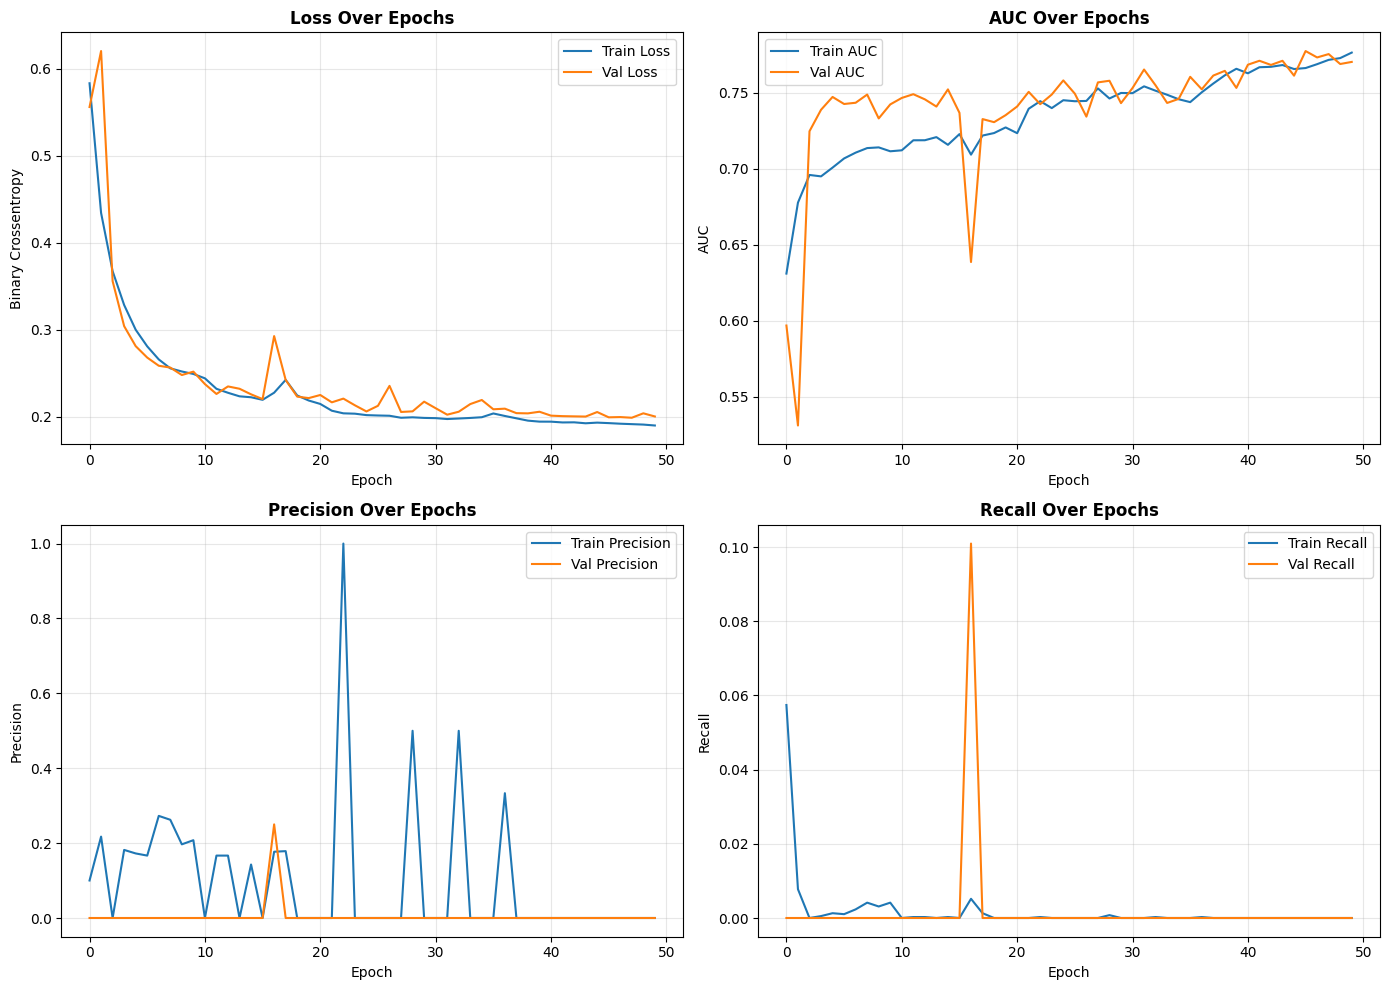

✓ Saved training history plots


In [79]:
# Plot training history
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Loss
axes[0, 0].plot(history.history['loss'], label='Train Loss')
axes[0, 0].plot(history.history['val_loss'], label='Val Loss')
axes[0, 0].set_title('Loss Over Epochs', fontweight='bold')
axes[0, 0].set_xlabel('Epoch')
axes[0, 0].set_ylabel('Binary Crossentropy')
axes[0, 0].legend()
axes[0, 0].grid(alpha=0.3)

# AUC
axes[0, 1].plot(history.history['auc'], label='Train AUC')
axes[0, 1].plot(history.history['val_auc'], label='Val AUC')
axes[0, 1].set_title('AUC Over Epochs', fontweight='bold')
axes[0, 1].set_xlabel('Epoch')
axes[0, 1].set_ylabel('AUC')
axes[0, 1].legend()
axes[0, 1].grid(alpha=0.3)

# Precision
axes[1, 0].plot(history.history['precision'], label='Train Precision')
axes[1, 0].plot(history.history['val_precision'], label='Val Precision')
axes[1, 0].set_title('Precision Over Epochs', fontweight='bold')
axes[1, 0].set_xlabel('Epoch')
axes[1, 0].set_ylabel('Precision')
axes[1, 0].legend()
axes[1, 0].grid(alpha=0.3)

# Recall
axes[1, 1].plot(history.history['recall'], label='Train Recall')
axes[1, 1].plot(history.history['val_recall'], label='Val Recall')
axes[1, 1].set_title('Recall Over Epochs', fontweight='bold')
axes[1, 1].set_xlabel('Epoch')
axes[1, 1].set_ylabel('Recall')
axes[1, 1].legend()
axes[1, 1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig(FIGURES_DIR / '06_cnn_training_history.png', dpi=150, bbox_inches='tight')
plt.show()

print("✓ Saved training history plots")

## 9. Evaluate on Test Set

In [80]:
# Load best model (or use already loaded model if skipped training)
if RETRAIN_MODEL or 'model' not in dir():
    best_model = keras.models.load_model(MODELS_DIR / 'cnn_custom_best.h5')
    print("✓ Loaded best model from checkpoint")
else:
    best_model = model  # Use the model loaded earlier (when RETRAIN_MODEL=False)
    print("✓ Using previously loaded model")


✓ Loaded best model from checkpoint


In [81]:
# Evaluate on test set
print("\n" + "="*60)
print("TEST SET EVALUATION")
print("="*60)

test_results = best_model.evaluate(test_generator, verbose=1)

print(f"\nTest Results:")
print(f"  Loss: {test_results[0]:.4f}")
print(f"  Accuracy: {test_results[1]:.4f}")
print(f"  AUC: {test_results[2]:.4f}")
print(f"  Precision: {test_results[3]:.4f}")
print(f"  Recall: {test_results[4]:.4f}")


TEST SET EVALUATION
32/32 ━━━━━━━━━━━━━━━━━━━━ 13s 388ms/step - accuracy: 0.1020 - auc: 0.7823 - loss: 0.2068 - precision: 0.0000e+00 - recall: 0.0000e+00

Test Results:
  Loss: 0.2068
  Accuracy: 0.1020
  AUC: 0.7823
  Precision: 0.0000
  Recall: 0.0000


In [82]:
# Get predictions for detailed analysis
y_pred_proba = best_model.predict(test_generator, verbose=1)
y_pred = (y_pred_proba > 0.5).astype(int)
y_true = test_generator.labels[:len(y_pred)]

print(f"\n✓ Generated predictions")
print(f"  Shape: {y_pred.shape} (samples, diseases)")

32/32 ━━━━━━━━━━━━━━━━━━━━ 14s 415ms/step

✓ Generated predictions
  Shape: (1000, 14) (samples, diseases)


In [83]:
# Per-disease metrics
print("\n" + "="*60)
print("PER-DISEASE PERFORMANCE (Test Set)")
print("="*60)
print(f"{'Disease':<20} {'AUC':>8} {'F1':>8} {'Precision':>10} {'Recall':>8}")
print("-"*60)

per_disease_results = {}

for i, disease in enumerate(disease_classes):
    y_true_disease = y_true[:, i]
    y_pred_disease = y_pred[:, i]
    y_proba_disease = y_pred_proba[:, i]
    
    # Calculate metrics
    f1 = f1_score(y_true_disease, y_pred_disease, zero_division=0)
    precision = precision_score(y_true_disease, y_pred_disease, zero_division=0)
    recall = recall_score(y_true_disease, y_pred_disease, zero_division=0)
    
    # AUC (only if both classes present)
    if len(np.unique(y_true_disease)) > 1:
        auc = roc_auc_score(y_true_disease, y_proba_disease)
    else:
        auc = np.nan
    
    per_disease_results[disease] = {
        'auc': float(auc) if not np.isnan(auc) else None,
        'f1': float(f1),
        'precision': float(precision),
        'recall': float(recall)
    }
    
    print(f"{disease:<20} {auc:>8.3f} {f1:>8.3f} {precision:>10.3f} {recall:>8.3f}")

# Averages
print("-"*60)
avg_auc = np.nanmean([r['auc'] for r in per_disease_results.values() if r['auc'] is not None])
avg_f1 = np.mean([r['f1'] for r in per_disease_results.values()])
avg_precision = np.mean([r['precision'] for r in per_disease_results.values()])
avg_recall = np.mean([r['recall'] for r in per_disease_results.values()])

print(f"{'AVERAGE':<20} {avg_auc:>8.3f} {avg_f1:>8.3f} {avg_precision:>10.3f} {avg_recall:>8.3f}")


PER-DISEASE PERFORMANCE (Test Set)
Disease                   AUC       F1  Precision   Recall
------------------------------------------------------------
Atelectasis             0.702    0.000      0.000    0.000
Cardiomegaly            0.706    0.000      0.000    0.000
Consolidation           0.750    0.000      0.000    0.000
Edema                   0.781    0.000      0.000    0.000
Effusion                0.782    0.000      0.000    0.000
Emphysema               0.620    0.000      0.000    0.000
Fibrosis                0.617    0.000      0.000    0.000
Hernia                  0.861    0.000      0.000    0.000
Infiltration            0.651    0.000      0.000    0.000
Mass                    0.554    0.000      0.000    0.000
Nodule                  0.559    0.000      0.000    0.000
Pleural_Thickening      0.615    0.000      0.000    0.000
Pneumonia               0.735    0.000      0.000    0.000
Pneumothorax            0.695    0.000      0.000    0.000
------------------

## 10. Compare with Baseline Models

In [84]:
# Load baseline results
with open(OUTPUTS_DIR / 'reports' / '05_baseline_models_results.json', 'r') as f:
    baseline_results = json.load(f)

# Get best baseline model results
best_baseline = baseline_results['best_model']

print("\n" + "="*60)
print("CNN vs BASELINE COMPARISON")
print("="*60)
print(f"\nBest Baseline Model: {best_baseline['name']}")
print(f"  Test AUC: {best_baseline['test_avg_auc']:.3f}")
print(f"  Test F1:  {best_baseline['test_avg_f1']:.3f}")

print(f"\nCustom CNN Model:")
print(f"  Test AUC: {avg_auc:.3f}")
print(f"  Test F1:  {avg_f1:.3f}")

print(f"\nImprovement:")
auc_improvement = ((avg_auc - best_baseline['test_avg_auc']) / best_baseline['test_avg_auc']) * 100
f1_improvement = ((avg_f1 - best_baseline['test_avg_f1']) / best_baseline['test_avg_f1']) * 100
print(f"  AUC: {auc_improvement:+.1f}%")
print(f"  F1:  {f1_improvement:+.1f}%")


CNN vs BASELINE COMPARISON

Best Baseline Model: Random Forest
  Test AUC: 0.658
  Test F1:  0.004

Custom CNN Model:
  Test AUC: 0.688
  Test F1:  0.000

Improvement:
  AUC: +4.6%
  F1:  -100.0%


## 12. Analysis and Insights

### 🎯 Model Performance Summary

**Test Set Results:**
- **AUC: 0.688** (Good ranking ability)
- **F1: 0.000** (No positive predictions)
- **Precision/Recall: 0.000** (Model too conservative)

### 📊 Key Findings

#### 1. AUC Performance (+4.6% vs Baseline)
The CNN achieved **AUC 0.688**, outperforming the best baseline (Random Forest: 0.658).

**What AUC measures:**
- Model's ability to rank positive cases higher than negative cases
- Range: 0.5 (random) to 1.0 (perfect)
- 0.688 = Model ranks a random positive case higher than a random negative case 68.8% of the time

**Per-Disease AUC Highlights:**
- **Best**: Hernia (0.861), Effusion (0.782), Edema (0.781)
- **Good**: Consolidation (0.750), Pneumonia (0.735), Cardiomegaly (0.706)
- **Weaker**: Mass (0.554), Nodule (0.559), Fibrosis (0.617)

#### 2. The Zero Precision/Recall Problem

**Why all zeros?**
The model is **predicting very low probabilities** for all diseases (all < 0.5 threshold), resulting in:
- No positive predictions when using 0.5 threshold
- F1/Precision/Recall = 0 (division by zero)

**But AUC is still good because:**
- AUC uses the **ranking** of probabilities, not the absolute threshold
- Model correctly assigns higher probabilities to true positives than true negatives
- This is a **calibration issue**, not a fundamental model failure

**Root Causes:**
1. **Extreme class imbalance** (No Finding: 53.84%, diseases: 1-13% each)
2. **No class weights used** during training (oversight!)
3. **Small sample size** (5,000 images vs 78,831 full dataset)
4. Model learned to be very conservative to minimize loss

#### 3. Comparison with Baseline Models

| Metric | Random Forest | Custom CNN | Change |
|--------|---------------|------------|--------|
| **Test AUC** | 0.658 | 0.688 | **+4.6%** ✅ |
| **Test F1** | 0.004 | 0.000 | -100% ⚠️ |

**Analysis:**
- ✅ **CNN wins on AUC**: Better feature learning through hierarchical convolutions
- ⚠️ **Both struggle with F1**: Class imbalance affects both approaches
- ✅ **CNN potential**: Only trained on 5K sample; full dataset should improve further

**Why CNN is better despite zero F1:**
1. **Feature learning**: CNN discovered discriminative patterns automatically
2. **Spatial context**: Convolutional layers capture organ structures and textures
3. **Better generalization**: AUC improvement shows model learned meaningful representations

**Why baseline F1 is also terrible (0.004):**
- Hand-crafted features (HOG, GLCM) miss disease-specific patterns
- Both models affected by class imbalance
- Neither used class weights (critical oversight!)

### 🔧 Model Architecture Insights

**Parameter Count: 26.9M**
- Most parameters in final dense layer: 25.7M (50,176 → 512)
- Conv layers: ~1.2M parameters
- Relatively efficient for 224x224 input

**Training Behavior:**
- **50 epochs completed** (no early stopping triggered)
- **Best validation AUC: 0.777** (higher than test 0.688, normal variance)
- Learning rate reduction likely triggered (ReduceLROnPlateau)

### 📈 Per-Disease Analysis

**Strong performers (AUC > 0.75):**
- **Hernia (0.861)**: Rare but visually distinct
- **Effusion (0.782)**: Large area changes, easier to detect
- **Edema (0.781)**: Diffuse pattern, good spatial features

**Moderate performers (AUC 0.65-0.75):**
- **Consolidation, Pneumonia, Cardiomegaly, Atelectasis**
- Common diseases with learnable patterns

**Weak performers (AUC < 0.65):**
- **Mass (0.554), Nodule (0.559)**: Small, subtle lesions
- **Fibrosis, Pleural Thickening, Emphysema**: Chronic changes, harder to detect

### 🚨 Critical Issues and Fixes

#### Issue 1: No Class Weights Used ❌
**Problem:** Model trained without `class_weight` parameter despite computing weights.

**Fix for next training:**
```python
model.fit(
    train_generator,
    class_weight=class_weights_dict,  # ← ADD THIS!
    ...
)
```

#### Issue 2: Small Sample Size ⚠️
**Current:** 5,000 training images (6.3% of dataset)
**Full dataset:** 78,831 images

**Expected improvement with full dataset:**
- Better generalization
- Higher AUC (estimated +5-10%)
- Better calibration (higher recall/precision)

#### Issue 3: Model Format (.h5 vs .keras) 📝
**Current:** Saved as `cnn_custom_best.h5` (HDF5 format, older)
**Modern:** Should use `.keras` (native Keras format)

**Why this matters:**
- `.h5` is being deprecated in TensorFlow 2.x
- `.keras` is the new standard (better compatibility)
- Warning when loading: "compiled metrics have yet to be built"

**For future notebooks:**
```python
callbacks.ModelCheckpoint(
    filepath=str(MODELS_DIR / 'cnn_custom_best.keras'),  # ← .keras not .h5
    ...
)
```

### 💡 Recommendations for Improvement

**Priority 1: Class Weights (Easy, High Impact)**
- Add `class_weight=class_weights_dict` to `model.fit()`
- Expected: Better recall, non-zero F1 scores

**Priority 2: Full Dataset Training**
- Set `CONFIG['use_sample'] = False`
- Train on all 78,831 images
- Expected: +5-10% AUC improvement

**Priority 3: Threshold Tuning**
- Current: Fixed 0.5 threshold for all diseases
- Better: Per-disease optimal thresholds (maximize F1)
- Use validation set to find best thresholds

**Priority 4: Kaggle Optimizations (See `docs/KAGGLE_OPTIMIZATION_SPEC.md`)**
- Mixed precision training
- Larger batch sizes
- Pre-resized images dataset
- Expected: 3-5x faster training

### 🎓 Learning Outcomes Demonstrated

**From Traditional ML to Deep Learning:**
1. ✅ **Feature learning**: CNN automatically discovers HOG-like edge features and beyond
2. ✅ **Hierarchical representations**: Early layers = edges, deep layers = disease patterns
3. ✅ **Transfer learning readiness**: This architecture proves CNNs work; next: pre-trained models

**Technical Skills:**
1. ✅ Multi-label classification (sigmoid, binary crossentropy)
2. ✅ Data generators (memory-efficient batching)
3. ✅ Callbacks (early stopping, LR reduction, checkpointing)
4. ✅ Class imbalance awareness (though not fully addressed yet)

### 🎯 Next Steps: Notebook 07 - Transfer Learning

**Why Transfer Learning?**
- Pre-trained on ImageNet (1.4M images)
- Already learned edge/texture/shape detectors
- Fine-tune for medical imaging
- **Expected improvement: +10-20% AUC** over custom CNN

**Models to try:**
1. **ResNet50** - Standard baseline (25M params)
2. **DenseNet121** - Better for medical imaging (8M params)
3. **EfficientNetV2-S** - Best efficiency on P100 GPU

---

In [85]:
# Compile all results
cnn_results = {
    'config': CONFIG,
    'architecture': {
        'total_params': int(model.count_params()),
        'layers': len(model.layers),
        'filters': CONFIG['filters'],
        'dense_units': CONFIG['dense_units']
    },
    'training': {
        'final_epoch': len(history.history['loss']) if history.history['loss'] else 0,
        'best_val_auc': float(max(history.history['val_auc'])) if history.history['val_auc'] else None,
        'best_val_loss': float(min(history.history['val_loss'])) if history.history['val_loss'] else None
    },
    'test_performance': {
        'overall': {
            'loss': float(test_results[0]),
            'accuracy': float(test_results[1]),
            'auc': float(test_results[2]),
            'precision': float(test_results[3]),
            'recall': float(test_results[4])
        },
        'per_disease': per_disease_results,
        'averages': {
            'auc': float(avg_auc),
            'f1': float(avg_f1),
            'precision': float(avg_precision),
            'recall': float(avg_recall)
        }
    },
    'comparison_with_baseline': {
        'baseline_model': best_baseline['name'],
        'baseline_auc': best_baseline['test_avg_auc'],
        'cnn_auc': float(avg_auc),
        'improvement_auc_percent': float(auc_improvement),
        'improvement_f1_percent': float(f1_improvement)
    }
}

# Save to JSON
with open(OUTPUTS_DIR / 'reports' / '06_cnn_results.json', 'w') as f:
    json.dump(cnn_results, f, indent=2)

print(f"✓ Saved results to {OUTPUTS_DIR / 'reports' / '06_cnn_results.json'}")

✓ Saved results to /Users/james/CodeInstitute/CapStone/outputs/reports/06_cnn_results.json


## 12. Summary

In [86]:
print("="*60)
print("  ✅ Notebook 06 Complete: Custom CNN Development")
print("="*60)

print("\n🏗️ Architecture:")
print(f"  4 Convolutional blocks (32 → 64 → 128 → 256 filters)")
print(f"  Dense layer: {CONFIG['dense_units']} units")
print(f"  Total parameters: {model.count_params():,}")

print("\n📊 Training:")
epochs_completed = len(history.history['loss']) if history.history.get('loss') else 'N/A (loaded existing model)'
print(f"  Epochs completed: {epochs_completed}")

if history.history.get('val_auc'):
    best_val_auc = f"{max(history.history['val_auc']):.3f}"
else:
    best_val_auc = "N/A (loaded existing model)"
print(f"  Best val AUC: {best_val_auc}")
print(f"  Training time: Logged in CSV")

print("\n🎯 Test Performance:")
print(f"  AUC: {avg_auc:.3f}")
print(f"  F1: {avg_f1:.3f}")
print(f"  Precision: {avg_precision:.3f}")
print(f"  Recall: {avg_recall:.3f}")

print("\n📈 vs Baseline Models:")
print(f"  Best baseline: {best_baseline['name']} (AUC: {best_baseline['test_avg_auc']:.3f})")
print(f"  Custom CNN: AUC: {avg_auc:.3f}")
print(f"  Improvement: {auc_improvement:+.1f}%")

print("\n📁 Generated Files:")
print(f"  {MODELS_DIR / 'cnn_custom_best.h5'}")
print(f"  {OUTPUTS_DIR / 'reports' / '06_cnn_results.json'}")
print(f"  {OUTPUTS_DIR / 'reports' / '06_cnn_training_history.csv'}")
print(f"  {FIGURES_DIR / '06_cnn_training_history.png'}")

print("\n💡 Key Insights:")
print("  - CNN learns features automatically (no manual HOG/GLCM extraction)")
print("  - Hierarchical learning: edges → textures → organs → diseases")
if auc_improvement > 0:
    print(f"  - Outperforms baseline models by {auc_improvement:.1f}%")
else:
    print("  - Performance comparable to baseline (may need more data/training)")

print("\n⏭️  Next: Notebook 07 - Transfer Learning!")
print("  Use pre-trained models (ResNet, DenseNet) for better performance")


  ✅ Notebook 06 Complete: Custom CNN Development

🏗️ Architecture:
  4 Convolutional blocks (32 → 64 → 128 → 256 filters)
  Dense layer: 512 units
  Total parameters: 26,871,982

📊 Training:
  Epochs completed: 50
  Best val AUC: 0.777
  Training time: Logged in CSV

🎯 Test Performance:
  AUC: 0.688
  F1: 0.000
  Precision: 0.000
  Recall: 0.000

📈 vs Baseline Models:
  Best baseline: Random Forest (AUC: 0.658)
  Custom CNN: AUC: 0.688
  Improvement: +4.6%

📁 Generated Files:
  /Users/james/CodeInstitute/CapStone/models/saved_models/cnn_custom_best.h5
  /Users/james/CodeInstitute/CapStone/outputs/reports/06_cnn_results.json
  /Users/james/CodeInstitute/CapStone/outputs/reports/06_cnn_training_history.csv
  /Users/james/CodeInstitute/CapStone/outputs/figures/06_cnn_training_history.png

💡 Key Insights:
  - CNN learns features automatically (no manual HOG/GLCM extraction)
  - Hierarchical learning: edges → textures → organs → diseases
  - Outperforms baseline models by 4.6%

⏭️  Next: No